In [1]:
import time
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
import idx2numpy # pip install idx2numpy
import gzip
import shutil
from pathlib import Path
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,Flatten # import my implmentation
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()
digits.images.shape

(1797, 8, 8)

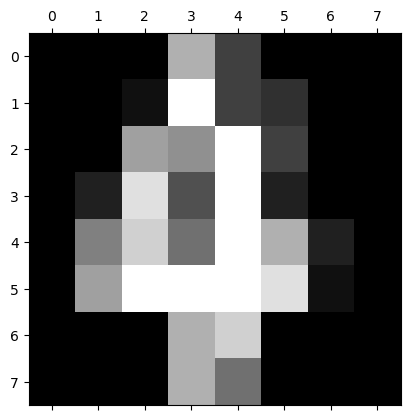

In [3]:
plt.matshow(digits.images[400], cmap="gray")

In [4]:
X=digits.images
y=digits.target
#digits.target_names  


In [5]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)
X_train=X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2]) # adding channel dimension
X_test=X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2]) # adding channel dimension

In [6]:
# normalization
X_max = np.max(X_train)
X_train = (X_train) / (X_max)
X_test = (X_test ) / (X_max)


In [7]:
y_train_one_hot=to_one_hot(y_train,10)
y_test_one_hot=to_one_hot(y_test,10)

In [8]:
X_train.shape

(1618, 1, 8, 8)

In [19]:
importlib.reload(deep_learning.model)
importlib.reload(deep_learning.utils)
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,AVGPooling,Flatten # import my implmentation
EPOCHS = 40
LR = 0.005

# CNN
model = SequentialNetwork(layers=[
    Convolution2D(kernel_size=(3,3),n_kernels=16, input_shape=(1,8,8), stride=1, padding=1, activation_function=ReLU(), lr=LR, seed=SEED,fast=True), #Output (16,8,8)
    Flatten(),
    Dense(inputs=1024, neurons=64, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=64, neurons=10, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())



Convolutional 2D layer with: 160 trainable parameters, 1024 neurons, 10240 connections, Input: (1, 8, 8),  Output: (16, 8, 8)
Flatten layer
Dense layer with: 65600 trainable parameters, 64 neurons, 65600 connections
Dense layer with: 650 trainable parameters, 10 neurons, 650 connections


In [20]:

start = time.perf_counter()
BATCH_SIZE=32#len(X_train)
n_batches = len(X_train) / BATCH_SIZE
for epoch in range(EPOCHS):
    epoch_loss = model._train_one_epoch(X_train,y_train_one_hot, BATCH_SIZE,False) # 
    #train and test evaluation
    train_preds = np.argmax(model.predict(X_train), axis=1)
    test_preds  = np.argmax(model.predict(X_test), axis=1)
    train_acc   = np.mean(train_preds == y_train)  
    test_acc    = np.mean(test_preds  == y_test)

    print(f"Epoch: {epoch+1} | Loss: {epoch_loss}  Loss/batch: {epoch_loss / n_batches} | Train acc: {train_acc:.2%} | Test acc: {test_acc:.2%}") #first loss/n_batches should be  2.3 — tha is log(10)
    #print(f"Epoch: {epoch+1} | Loss: {epoch_loss}  Loss/batch: {epoch_loss / n_batches} ")

loss=model.losses
end = time.perf_counter()
print(f"Elapsed time: {end - start} seconds")

Epoch: 1 | Loss: 116.5348643821646  Loss/batch: 2.3047686404383603 | Train acc: 28.00% | Test acc: 24.58%
Epoch: 2 | Loss: 108.57001930551765  Loss/batch: 2.1472438923217334 | Train acc: 52.47% | Test acc: 54.19%
Epoch: 3 | Loss: 101.29725843075873  Loss/batch: 2.0034068416466497 | Train acc: 67.24% | Test acc: 69.27%
Epoch: 4 | Loss: 93.22994110470366  Loss/batch: 1.8438554483006904 | Train acc: 74.35% | Test acc: 75.42%
Epoch: 5 | Loss: 84.25761916975374  Loss/batch: 1.6664053235056364 | Train acc: 77.75% | Test acc: 78.21%
Epoch: 6 | Loss: 74.64431365717171  Loss/batch: 1.4762781440231734 | Train acc: 81.27% | Test acc: 80.45%
Epoch: 7 | Loss: 65.07968521113982  Loss/batch: 1.2871136753748296 | Train acc: 83.93% | Test acc: 84.92%
Epoch: 8 | Loss: 56.20015222525461  Loss/batch: 1.1114986843066426 | Train acc: 85.72% | Test acc: 87.15%
Epoch: 9 | Loss: 48.441041966708944  Loss/batch: 0.9580428571907825 | Train acc: 86.84% | Test acc: 90.50%
Epoch: 10 | Loss: 41.95781392835451  Loss/b

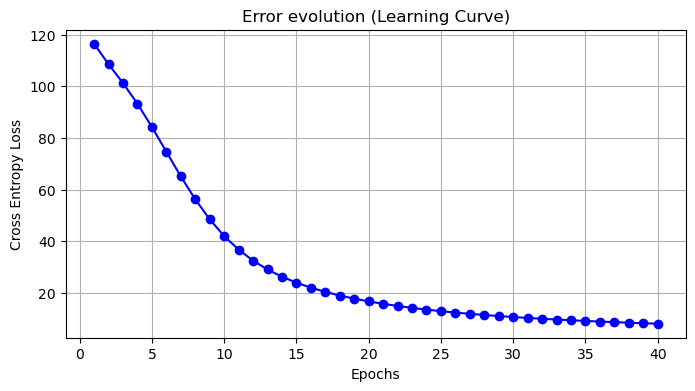

In [21]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [22]:
probs = model.predict(X_test)      
preds=np.argmax(probs,axis=1)

In [23]:
preds

array([4, 7, 5, 4, 6, 4, 4, 3, 4, 1, 3, 0, 3, 5, 4, 1, 3, 4, 4, 3, 4, 8, 2, 6, 2, 0, 9, 5, 9, 5, 0,
       7, 5, 5, 8, 2, 5, 3, 1, 7, 4, 9, 2, 0, 5, 2, 4, 8, 1, 1, 5, 1, 1, 3, 0, 6, 0, 6, 2, 2, 5, 4,
       2, 1, 9, 0, 2, 3, 4, 8, 9, 9, 9, 8, 9, 1, 3, 1, 4, 0, 1, 3, 5, 1, 3, 5, 7, 9, 6, 9, 6, 7, 5,
       7, 2, 1, 3, 7, 8, 1, 4, 3, 4, 8, 4, 6, 6, 9, 8, 9, 8, 9, 1, 1, 3, 8, 0, 8, 0, 6, 1, 0, 6, 0,
       5, 4, 5, 8, 4, 6, 8, 1, 3, 6, 1, 2, 9, 3, 3, 4, 9, 6, 1, 5, 4, 9, 8, 5, 4, 7, 4, 1, 6, 6, 4,
       6, 2, 8, 6, 8, 7, 8, 5, 1, 2, 7, 5, 7, 6, 9, 8, 2, 3, 7, 8, 7, 4, 4, 1])

In [24]:
y_test

array([4, 7, 5, 4, 6, 4, 4, 3, 4, 1, 3, 0, 3, 5, 4, 6, 3, 4, 4, 3, 4, 8, 2, 6, 2, 0, 9, 5, 9, 5, 0,
       7, 5, 5, 8, 2, 5, 3, 8, 7, 4, 9, 2, 0, 5, 2, 4, 8, 1, 1, 5, 1, 1, 3, 0, 6, 0, 6, 2, 2, 5, 4,
       2, 1, 9, 0, 2, 3, 4, 8, 9, 9, 9, 3, 9, 1, 3, 1, 4, 0, 1, 3, 5, 1, 3, 5, 7, 9, 6, 9, 6, 7, 5,
       7, 2, 1, 3, 7, 8, 1, 4, 3, 4, 8, 4, 6, 6, 9, 8, 9, 8, 9, 1, 1, 3, 8, 0, 8, 0, 6, 1, 0, 6, 0,
       5, 4, 8, 8, 4, 6, 8, 1, 3, 6, 1, 2, 9, 3, 3, 4, 9, 6, 1, 5, 4, 9, 8, 5, 4, 7, 4, 1, 6, 6, 4,
       6, 2, 8, 6, 8, 7, 8, 5, 1, 2, 4, 5, 7, 6, 9, 8, 2, 3, 7, 8, 7, 4, 4, 1])

In [25]:
accuracy = np.mean(preds == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.21%
